# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Juan Sebastian Diaz Campos, 2026

# 04_modelo

En esta plantilla entregada por el profesor Diego Fernando Marin se llevará a cabo el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [140]:
# Librerías a utilizar en este módulo
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from prophet.serialize import model_to_json
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [142]:
cwd = os.getcwd() # current working directory
trusted_dir = cwd + '/../data/trusted/'
surface_dir = cwd + '/../data/surface/'

In [143]:
df = pd.read_csv(trusted_dir + 'datos_limpios_ml.csv', parse_dates=["Fecha_apertura", "Fecha_cierre"])

## 1. Diseñar el Modelo

In [144]:
print(f"Valor mínimo del dataset: {df["Fecha_apertura"].min()}")
print(f"Valor máximo del dataset: {df["Fecha_apertura"].max()}")
print(f"Cantidad de registros del dataset: {len(df)}")

Valor mínimo del dataset: 2024-05-06 14:12:53
Valor máximo del dataset: 2026-06-30 15:48:23
Cantidad de registros del dataset: 5877


In [145]:
## Construyendo Modelo con prónostico Diario
serie_diaria = (df.groupby(pd.Grouper(key="Fecha_apertura", freq="D")).size().reset_index(name="y"))
serie_diaria.rename(columns={"Fecha_apertura": "ds"},inplace=True)
serie_diaria.head()

,ds,y
0,2024-05-06,2
1,2024-05-07,0
2,2024-05-08,5
3,2024-05-09,1
4,2024-05-10,6


In [146]:
## Construyendo Modelo con prónostico Semanal
serie_semanal = (df.groupby(pd.Grouper(key="Fecha_apertura", freq="W")).size().reset_index(name="y"))
serie_semanal.rename(columns={"Fecha_apertura": "ds"},inplace=True)
serie_semanal.head()

,ds,y
0,2024-05-12,14
1,2024-05-19,37
2,2024-05-26,30
3,2024-06-02,36
4,2024-06-09,41


### Comparación Temporalidad Diaria VS Semanal

In [147]:
resumen = pd.DataFrame({
    "Frecuencia":["Diaria","Semanal"],
    "Observaciones":[len(serie_diaria),len(serie_semanal)],
    "Promedio":[serie_diaria["y"].mean(),serie_semanal["y"].mean()],
    "DesvStd":[serie_diaria["y"].std(),serie_semanal["y"].std()],
    "Mínimo":[serie_diaria["y"].min(),serie_semanal["y"].min()],
    "Máximo":[serie_diaria["y"].max(),serie_semanal["y"].max()],
    "Valores en 0":[(serie_diaria["y"] == 0).sum(),(serie_semanal["y"] == 0).sum()]
})

resumen ## Mostrar tabla

,Frecuencia,Observaciones,Promedio,DesvStd,Mínimo,Máximo,Valores en 0
0,Diaria,786,7.477099,6.902422,0,42,154
1,Semanal,113,52.008850,21.342235,10,120,0


### Decisión de frecuencia y variables complementarias

Según la conclusión del EDA (`03_EDA.ipynb`), la variable objetivo del proyecto es la **cantidad de solicitudes abiertas por día**. Por lo tanto, la `Serie Diaria` será el modelo de producción; la serie semanal se conserva únicamente como comparación de referencia (demostrando menor varianza relativa, pero de menor utilidad operativa para el negocio).

En el EDA también se identificó el **tipo de día (hábil/festivo)** como variable relevante para complementar el modelo. Se incorpora como `regresor externo de Prophet`, calculado con la misma librería `holidays` (calendario de Colombia) ya utilizada en `02_limpieza.ipynb`, manteniendo consistencia entre etapas del proyecto.

In [148]:
festivos_colombia = holidays.Colombia(years=range(serie_diaria["ds"].dt.year.min(), serie_diaria["ds"].dt.year.max() + 1))

def es_dia_habil(fecha):
    if fecha.weekday() >= 5:
        return 0
    if fecha.date() in festivos_colombia:
        return 0
    return 1

serie_diaria["es_habil"] = serie_diaria["ds"].apply(es_dia_habil)
serie_diaria.head()

,ds,y,es_habil
0,2024-05-06,2,1
1,2024-05-07,0,1
2,2024-05-08,5,1
3,2024-05-09,1,1
4,2024-05-10,6,1


## 2. Entrenar el Modelo

In [149]:
def entrenar_prophet(serie, regresores=None):
    regresores = regresores or []
    train_size = int(len(serie) * 0.8)
    train = serie.iloc[:train_size].copy()
    test = serie.iloc[train_size:].copy()
    train["ds"] = pd.to_datetime(train["ds"]).astype("datetime64[ns]")

    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05
    )
    for regresor in regresores:
        modelo.add_regressor(regresor)

    modelo.fit(train[["ds", "y"] + regresores])
    future = test[["ds"] + regresores]
    forecast = modelo.predict(future)

    # La cantidad de solicitudes no puede ser negativa: se recorta en 0.
    forecast["yhat"] = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

    return modelo, train, test, forecast

In [150]:
modelo_diario, train_d, test_d, forecast_d = entrenar_prophet(serie_diaria, regresores=["es_habil"])

In [151]:
modelo_semanal,train_s,test_s,forecast_s = entrenar_prophet(serie_semanal)

## 3. Verificar el Modelo - Desempeño de Pruebas

In [152]:
def evaluar(test,forecast):
    mae = mean_absolute_error(test["y"],forecast["yhat"])
    rmse = np.sqrt(mean_squared_error(test["y"],forecast["yhat"]))
    return mae,rmse

In [153]:
mae_d,rmse_d = evaluar(test_d,forecast_d)
mae_s,rmse_s = evaluar(test_s,forecast_s)

In [154]:
comparacion = pd.DataFrame({
    "Modelo":["Prophet Diario","Prophet Semanal"],
    "MAE":[round(mae_d,2),round(mae_s,2)],
    "RMSE":[round(rmse_d,2),round(rmse_s,2)]
})

comparacion ## Mostrar tabla

,Modelo,MAE,RMSE
0,Prophet Diario,4.12,6.00
1,Prophet Semanal,36.37,39.33


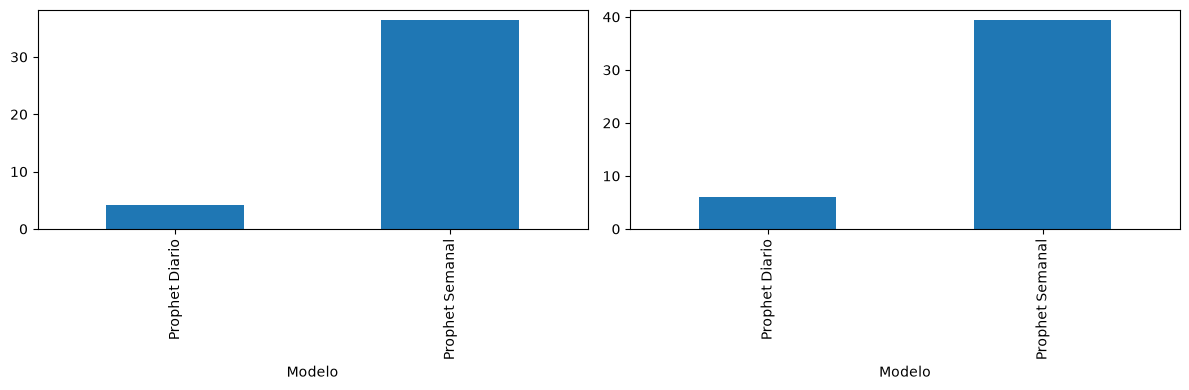

In [155]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

comparacion.plot.bar(x="Modelo",y="MAE",ax=ax[0],legend=False)
comparacion.plot.bar(x="Modelo",y="RMSE",ax=ax[1],legend=False)
plt.tight_layout()
plt.show()

In [156]:
comparacion_diaria = test_d[["ds", "y"]].copy()
comparacion_diaria["Prediccion"] = forecast_d["yhat"].values
comparacion_diaria.head()

,ds,y,Prediccion
628,2026-01-24,0,2.304336
629,2026-01-25,0,2.084014
630,2026-01-26,4,9.617023
631,2026-01-27,11,9.036355
632,2026-01-28,8,8.879950


In [157]:
def calcular_smape(y_real, y_pred):
    denominador = (y_real.abs() + y_pred.abs()).replace(0, np.nan)
    return (2 * (y_real - y_pred).abs() / denominador).mean() * 100

segmento = comparacion_diaria.merge(serie_diaria[["ds", "es_habil"]], on="ds", how="left")
filas = []

for etiqueta, grupo in [("Día hábil", segmento[segmento["es_habil"] == 1]),("Día no hábil", segmento[segmento["es_habil"] == 0]), ("Todos los días", segmento)]:
    dias_validos = ((grupo["y"].abs() + grupo["Prediccion"].abs()) != 0).sum()
    filas.append({
        "Tipo de día": etiqueta,
        "Tamaño": len(grupo),
        "Demanda promedio": round(grupo["y"].mean(), 2),
        "MAE": round(mean_absolute_error(grupo["y"], grupo["Prediccion"]), 2),
        "RMSE": round(np.sqrt(mean_squared_error(grupo["y"], grupo["Prediccion"])), 2),
        "sMAPE (%)": round(calcular_smape(grupo["y"], grupo["Prediccion"]), 2),
        "Días en sMAPE": dias_validos
    })

metricas_segmentadas = pd.DataFrame(filas)
metricas_segmentadas ## Mostrar tabla

,Tipo de día,Tamaño,Demanda promedio,MAE,RMSE,sMAPE (%),Días en sMAPE
0,Día hábil,104,10.79,5.68,7.31,64.16,104
1,Día no hábil,54,1.00,1.11,1.51,144.80,47
2,Todos los días,158,7.44,4.12,6.00,89.26,151


### Comparación contra un baseline ingenuo

Antes de asumir que Prophet aporta valor, se compara contra un baseline simple: predecir el mismo día de la semana anterior (`lag_7`), que ya captura la estacionalidad semanal sin necesidad de ningún modelo. Si Prophet no logra superar este baseline, no se justificaría su complejidad.

In [158]:
baseline = serie_diaria[["ds", "y"]].copy()
baseline["Baseline_lag7"] = baseline["y"].shift(7)

comparacion_diaria = comparacion_diaria.merge(baseline[["ds", "Baseline_lag7"]], on="ds", how="left")

mae_baseline = mean_absolute_error(comparacion_diaria["y"], comparacion_diaria["Baseline_lag7"])
rmse_baseline = np.sqrt(mean_squared_error(comparacion_diaria["y"], comparacion_diaria["Baseline_lag7"]))

comparacion_baseline = pd.DataFrame({
    "Modelo": ["Baseline (lag_7)", "Prophet Diario"],
    "MAE": [round(mae_baseline, 2), round(mae_final, 2)],
    "RMSE": [round(rmse_baseline, 2), round(rmse_final, 2)]
})

comparacion_baseline ## Mostrar tabla

,Modelo,MAE,RMSE
0,Baseline (lag_7),4.91,6.83
1,Prophet Diario,4.12,6.00


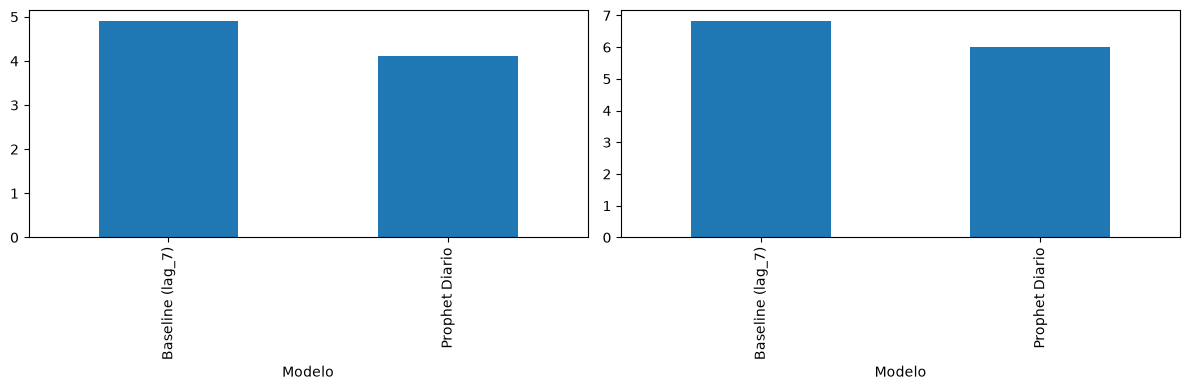

Prophet reduce el MAE en 16.2% frente al baseline lag_7


In [159]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
comparacion_baseline.plot.bar(x="Modelo", y="MAE", ax=ax[0], legend=False)
comparacion_baseline.plot.bar(x="Modelo", y="RMSE", ax=ax[1], legend=False)
plt.tight_layout()
plt.show()

mejora_mae = (1 - mae_final / mae_baseline) * 100
print(f"Prophet reduce el MAE en {mejora_mae:.1f}% frente al baseline lag_7")

In [160]:
comparativo = comparacion_diaria.merge(serie_diaria[["ds", "es_habil"]], on="ds", how="left")

filas = []
for etiqueta, grupo in [("Día hábil", comparativo[comparativo["es_habil"] == 1]),
                        ("Día no hábil", comparativo[comparativo["es_habil"] == 0]),
                        ("Todos los días", comparativo)]:
    mae_base = mean_absolute_error(grupo["y"], grupo["Baseline_lag7"])
    mae_prop = mean_absolute_error(grupo["y"], grupo["Prediccion"])
    filas.append({
        "Tipo de día": etiqueta,
        "MAE Baseline": round(mae_base, 2),
        "MAE Prophet": round(mae_prop, 2),
        "Mejora MAE (%)": round((1 - mae_prop / mae_base) * 100, 1),
        "RMSE Baseline": round(np.sqrt(mean_squared_error(grupo["y"], grupo["Baseline_lag7"])), 2),
        "RMSE Prophet": round(np.sqrt(mean_squared_error(grupo["y"], grupo["Prediccion"])), 2)
    })

comparativo_segmentado = pd.DataFrame(filas)
comparativo_segmentado ## Mostrar tabla

,Tipo de día,MAE Baseline,MAE Prophet,Mejora MAE (%),RMSE Baseline,RMSE Prophet
0,Día hábil,6.19,5.68,8.3,7.85,7.31
1,Día no hábil,2.44,1.11,54.7,4.21,1.51
2,Todos los días,4.91,4.12,16.2,6.83,6.00


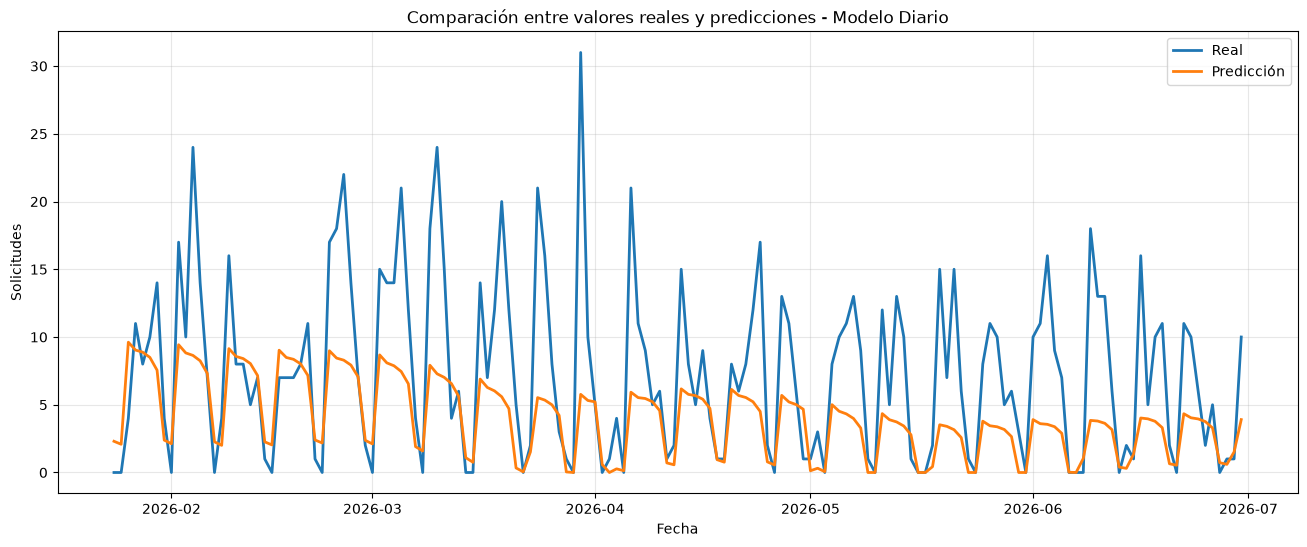

In [161]:
plt.figure(figsize=(16, 6))

plt.plot(
    comparacion_diaria["ds"],
    comparacion_diaria["y"],
    label="Real",
    linewidth=2
)

plt.plot(
    comparacion_diaria["ds"],
    comparacion_diaria["Prediccion"],
    label="Predicción",
    linewidth=2
)

plt.title("Comparación entre valores reales y predicciones - Modelo Diario")
plt.xlabel("Fecha")
plt.ylabel("Solicitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Análisis de residuales

Verificar que el error (real - predicción) no tenga sesgo sistemático ni patrones remanentes en el tiempo.

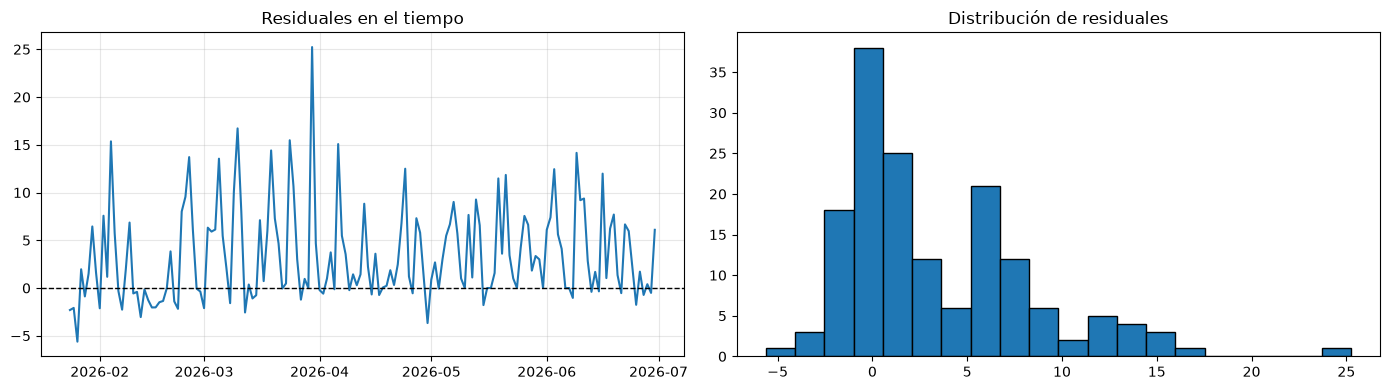

Residual promedio: 3.42 (cercano a 0 indica ausencia de sesgo sistemático)


In [162]:
residuales = comparacion_diaria["y"] - comparacion_diaria["Prediccion"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(comparacion_diaria["ds"], residuales)
ax[0].axhline(0, color="black", linewidth=1, linestyle="--")
ax[0].set_title("Residuales en el tiempo")
ax[0].grid(alpha=0.3)

ax[1].hist(residuales, bins=20, edgecolor="black")
ax[1].set_title("Distribución de residuales")

plt.tight_layout()
plt.show()

print(f"Residual promedio: {residuales.mean():.2f} (cercano a 0 indica ausencia de sesgo sistemático)")

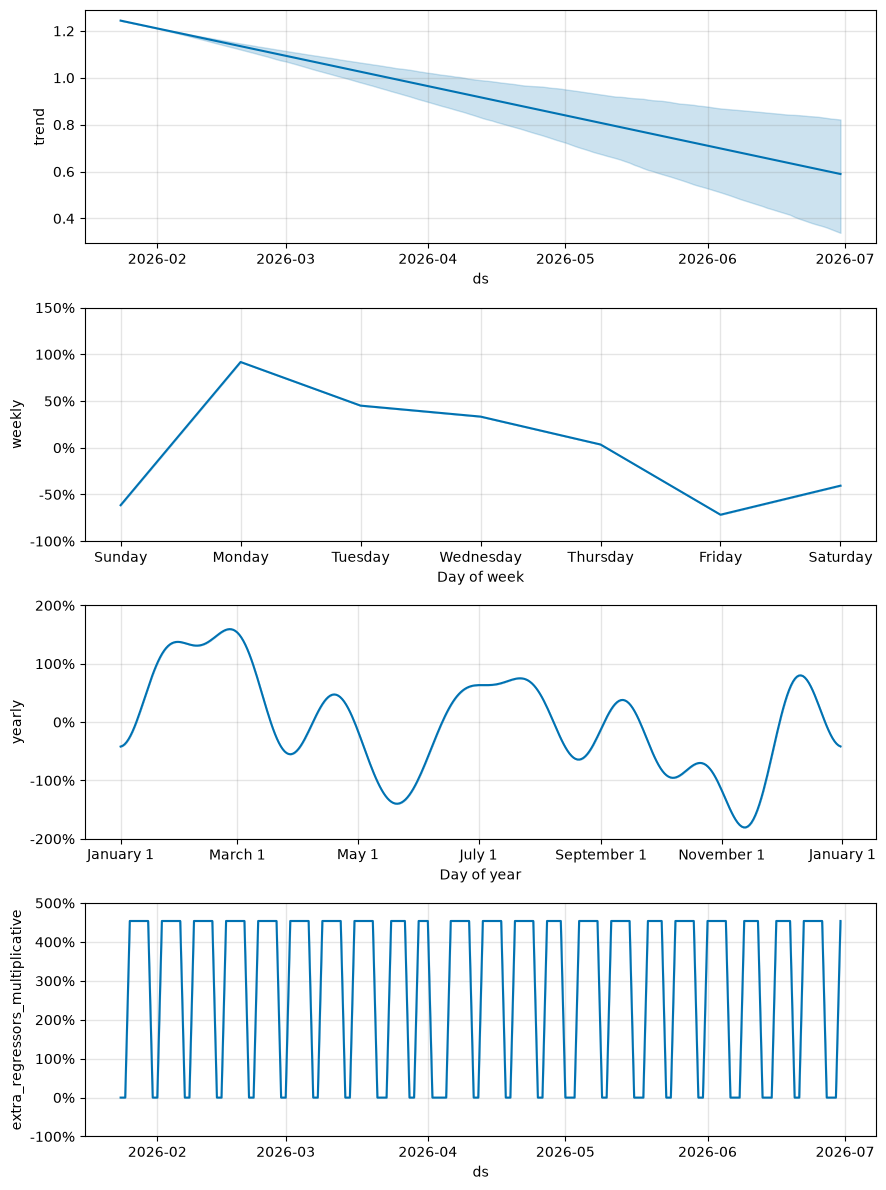

In [163]:
modelo_diario.plot_components(forecast_d)
plt.show()

## 4. Estructuración del Modelo Final

**Aclaración:** `modelo_diario` se entrenó únicamente con el 80% inicial del histórico (hasta ~2026-01-23) para poder validarlo contra un conjunto de prueba real, con los resultados evaluados arriba. Para proyectar los próximos 120 días **a partir de la última fecha disponible del histórico (2026-06-30)**, se reentrena Prophet con el 100% de los datos, usando los mismos hiperparámetros y el regresor `es_habil` ya validados.

In [164]:
modelo_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05
)
modelo_final.add_regressor("es_habil")
modelo_final.fit(serie_diaria[["ds", "y", "es_habil"]])

### Validación cruzada temporal (rolling origin)

Un único split de entrenamiento/prueba (usado en la sección de Verificación) depende de que ese periodo de prueba sea representativo. Prophet ofrece el equivalente de `TimeSeriesSplit`: `cross_validation` reentrena el modelo varias veces con distintos puntos de corte y evalúa siempre sobre el mismo horizonte, dando una métrica promedio más robusta que un solo punto de corte.

In [165]:
df_cv = cross_validation(modelo_final, initial="548 days", period="30 days", horizon="120 days")
df_metrics = performance_metrics(df_cv)

df_metrics[["horizon", "mae", "rmse"]]

  0%|          | 0/4 [00:00<?, ?it/s]

,horizon,mae,rmse
0,12 days,3.637838,5.090235
1,13 days,3.325878,4.816721
2,14 days,3.763917,5.542613
3,15 days,3.625387,5.319387
4,16 days,3.226669,4.765602
...,...,...,...
104,116 days,4.994814,6.899918
105,117 days,4.957458,6.923291
106,118 days,5.262899,7.888561
107,119 days,5.130867,7.572554


In [166]:
print(f"MAE promedio (validación cruzada, {df_cv['cutoff'].nunique()} cortes): {df_metrics['mae'].mean():.2f}")
print(f"MAE del split único (sección de Verificación): {mae_final:.2f}")

MAE promedio (validación cruzada, 4 cortes): 4.42
MAE del split único (sección de Verificación): 4.12


In [167]:
future = modelo_final.make_future_dataframe(periods=120, freq="D")

In [168]:
festivos_futuro = holidays.Colombia(years=range(future["ds"].dt.year.min(), future["ds"].dt.year.max() + 1))

def es_dia_habil_futuro(fecha):
    if fecha.weekday() >= 5:
        return 0
    if fecha.date() in festivos_futuro:
        return 0
    return 1

future["es_habil"] = future["ds"].apply(es_dia_habil_futuro)
forecast_futuro = modelo_final.predict(future)
forecast_futuro["yhat"] = forecast_futuro["yhat"].clip(lower=0)
forecast_futuro["yhat_lower"] = forecast_futuro["yhat_lower"].clip(lower=0)
forecast_futuro["dia_habil"] = future["es_habil"].values

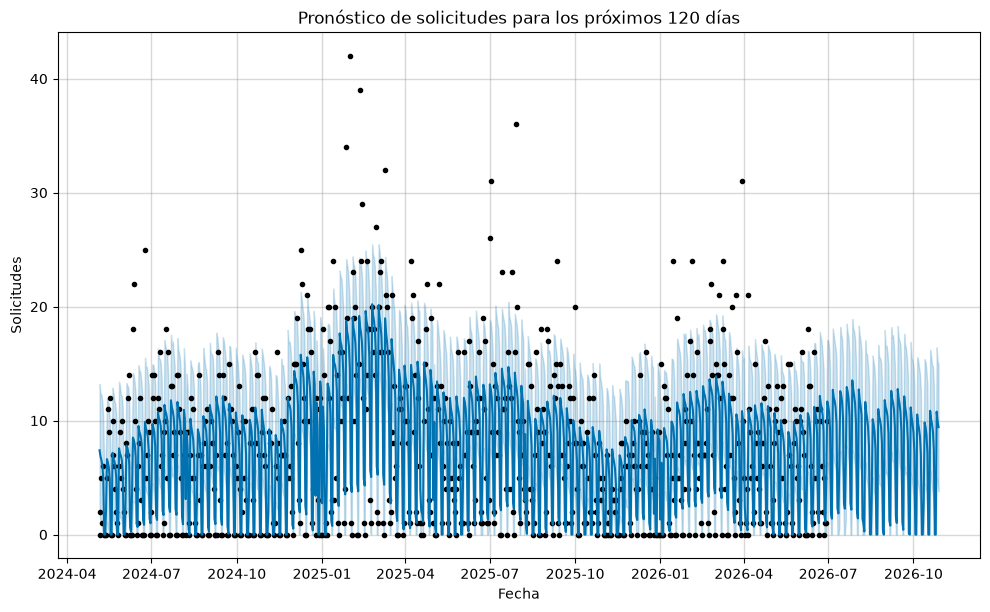

In [169]:
fig = modelo_final.plot(forecast_futuro)
plt.title("Pronóstico de solicitudes para los próximos 120 días")
plt.xlabel("Fecha")
plt.ylabel("Solicitudes")
plt.grid(alpha=0.3)
plt.show()

### Pronóstico por tipo de solicitud

Para desagregar la demanda por tipo se entrena un modelo Prophet **independiente por cada tipo**, en lugar de repartir el total según proporciones fijas. La diferencia es sustantiva: el reparto proporcional le asigna a todas las categorías la misma forma de curva escalada por un porcentaje, mientras que un modelo por tipo permite que cada uno tenga su propia tendencia y estacionalidad.

**Alcance y limitaciones declaradas:**

- Se modelan `DESBLOQUEO` (22.8% de días en cero), `CREACION` (51.4%) y `OTRA SOLICITUD` (49.9%), que concentran el 99.1% del volumen.
- `MODIFICACION` (93.1% de días en cero) y `ELIMINACION` (98.2%, 15 registros en dos años) **no se modelan**: su serie diaria es demasiado rala para estimar componentes temporales. Representan menos del 1% del volumen.
- `CREACION` y `OTRA SOLICITUD` promedian ~1 solicitud diaria, por lo que sus modelos son considerablemente más ruidosos que el del total.
- La suma de los modelos individuales no coincide exactamente con el pronóstico del modelo total (problema de coherencia jerárquica). Se reporta la diferencia; **el modelo total (`modelo_final`) es la cifra oficial** y los modelos por tipo son desagregación indicativa.

In [185]:
TIPOS_MODELABLES = ["DESBLOQUEO", "CREACION", "OTRA SOLICITUD"]

rango_completo = pd.date_range(serie_diaria["ds"].min(), serie_diaria["ds"].max(), freq="D")
modelos_tipo = {}
pronosticos_tipo = {}

for tipo in TIPOS_MODELABLES:
    serie_tipo = (df[df["Tipo_solicitud_1"] == tipo]
                  .groupby(pd.Grouper(key="Fecha_apertura", freq="D")).size()
                  .reindex(rango_completo, fill_value=0)   # Rellena los días sin solicitudes de ese tipo
                  .reset_index())
    serie_tipo.columns = ["ds", "y"]
    serie_tipo["es_habil"] = serie_tipo["ds"].apply(es_dia_habil)

    modelo_tipo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05
    )
    modelo_tipo.add_regressor("es_habil")
    modelo_tipo.fit(serie_tipo[["ds", "y", "es_habil"]])

    future_tipo = modelo_tipo.make_future_dataframe(periods=120, freq="D")
    future_tipo["es_habil"] = future_tipo["ds"].apply(es_dia_habil_futuro)
    forecast_tipo = modelo_tipo.predict(future_tipo)
    forecast_tipo["yhat"] = forecast_tipo["yhat"].clip(lower=0)
    forecast_tipo["yhat_lower"] = forecast_tipo["yhat_lower"].clip(lower=0)

    modelos_tipo[tipo] = modelo_tipo
    pronosticos_tipo[tipo] = forecast_tipo

print(f"Modelos entrenados por tipo de solicitud: {list(modelos_tipo)}")

Modelos entrenados por tipo de solicitud: ['DESBLOQUEO', 'CREACION', 'OTRA SOLICITUD']


In [171]:
horizontes = {"30 días": 30, "90 días": 90, "120 días": 120}
ultima_fecha = serie_diaria["ds"].max()

filas = []
for tipo, forecast_tipo in pronosticos_tipo.items():
    solo_futuro = forecast_tipo[forecast_tipo["ds"] > ultima_fecha]
    fila = {"Tipo de solicitud": tipo}
    for etiqueta, dias in horizontes.items():
        fila[etiqueta] = int(round(solo_futuro.head(dias)["yhat"].sum()))
    filas.append(fila)

proyeccion_tipo = pd.DataFrame(filas)

## Verificación de coherencia: la suma de los modelos por tipo no tiene por qué
## coincidir exactamente con el pronóstico del modelo total (modelo_final).
futuro_total = forecast_futuro[forecast_futuro["ds"] > ultima_fecha]
for etiqueta, dias in horizontes.items():
    total_agregado = proyeccion_tipo[etiqueta].sum()
    total_modelo = int(round(futuro_total.head(dias)["yhat"].sum()))
    dif = (total_agregado / total_modelo - 1) * 100
    print(f"{etiqueta}: suma por tipo = {total_agregado} | modelo total = {total_modelo} | diferencia = {dif:+.1f}%")

proyeccion_tipo ## Mostrar tabla

30 días: suma por tipo = 270 | modelo total = 263 | diferencia = +2.7%
90 días: suma por tipo = 716 | modelo total = 699 | diferencia = +2.4%
120 días: suma por tipo = 922 | modelo total = 896 | diferencia = +2.9%


,Tipo de solicitud,30 días,90 días,120 días
0,DESBLOQUEO,203,541,708
1,CREACION,43,107,128
2,OTRA SOLICITUD,24,68,86


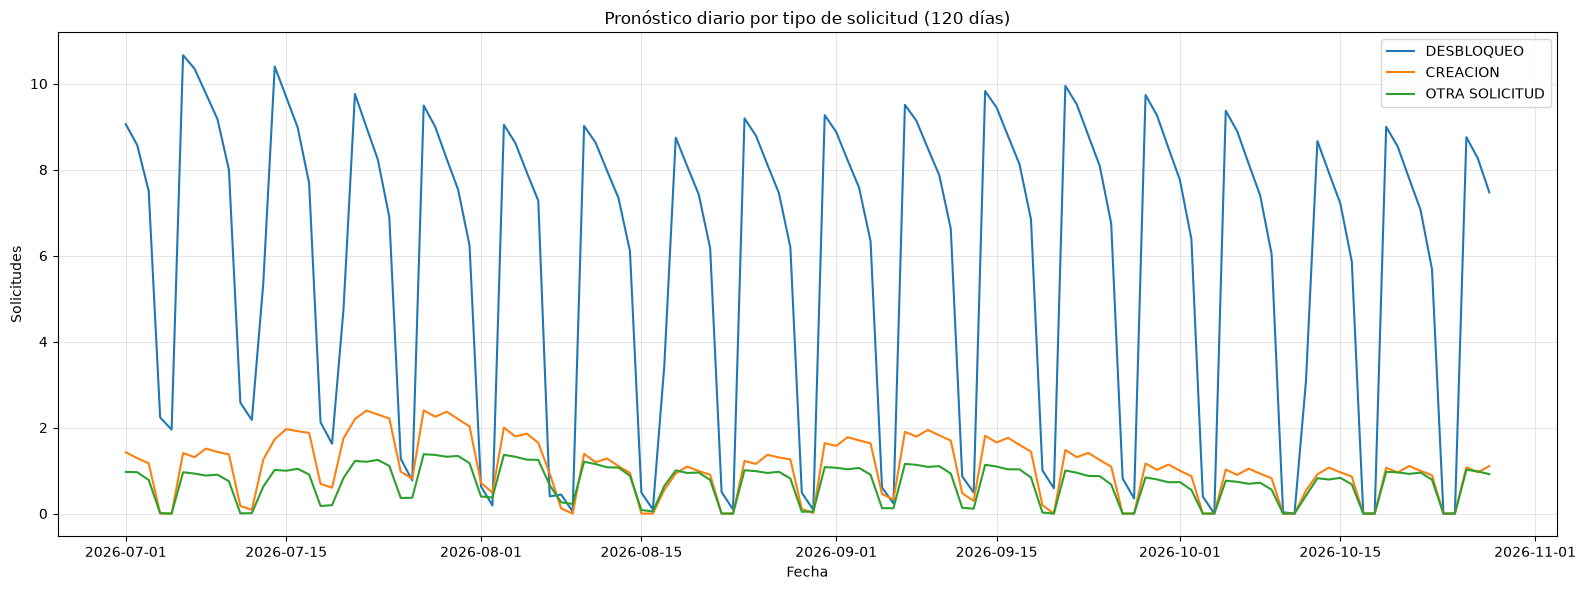

In [182]:
plt.figure(figsize=(16, 6))

for tipo, forecast_tipo in pronosticos_tipo.items():
    solo_futuro = forecast_tipo[forecast_tipo["ds"] > ultima_fecha]
    plt.plot(solo_futuro["ds"], solo_futuro["yhat"], label=tipo, linewidth=1.5)

plt.title("Pronóstico diario por tipo de solicitud (120 días)")
plt.xlabel("Fecha")
plt.ylabel("Solicitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [183]:
forecast_futuro[["ds", "yhat", "yhat_lower", "yhat_upper", "dia_habil"]].tail()

,ds,yhat,yhat_lower,yhat_upper,dia_habil
901,2026-10-24,0.000000,0.000000,5.183307,0
902,2026-10-25,0.000000,0.000000,4.344757,0
903,2026-10-26,10.785360,5.005476,16.429896,1
904,2026-10-27,9.940466,4.426842,15.229166,1
905,2026-10-28,9.429862,3.778362,14.964820,1


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

In [184]:
# Modelo total serializado en formato oficial de Prophet (portable entre versiones)
with open(surface_dir + "modelo_prophet_diario.json", "w") as f:
    f.write(model_to_json(modelo_final))

# Modelos por tipo de solicitud
for tipo, modelo_tipo in modelos_tipo.items():
    nombre = tipo.lower().replace(" ", "_")
    with open(surface_dir + f"modelo_prophet_{nombre}.json", "w") as f:
        f.write(model_to_json(modelo_tipo))

# Insumos para el Dashboard/Producto de Datos, listos para leer sin recargar el modelo
forecast_futuro[["ds", "yhat", "yhat_lower", "yhat_upper", "dia_habil"]].to_csv(surface_dir + "pronostico_120d.csv", index=False)
metricas.to_csv(surface_dir + "metricas_finales_modelo.csv", index=False)
proyeccion_tipo.to_csv(surface_dir + "proyeccion_por_tipo.csv", index=False)

# Serie diaria por tipo, para graficar la curva de cada uno en el Dashboard
pronostico_tipos = pd.concat(
    [fc[fc["ds"] > ultima_fecha][["ds", "yhat", "yhat_lower", "yhat_upper"]].assign(Tipo_solicitud=tipo)
     for tipo, fc in pronosticos_tipo.items()],
    ignore_index=True
)
pronostico_tipos.to_csv(surface_dir + "pronostico_120d_por_tipo.csv", index=False)

print(f"Modelos guardados en 'data/surface/': total + {len(modelos_tipo)} por tipo de solicitud")
print("Datos de apoyo guardados en 'data/surface/'...")

Modelos guardados en 'data/surface/': total + 3 por tipo de solicitud
Datos de apoyo guardados en 'data/surface/'...


**Producto de Datos**:

Dashboard: Tablero interactivo construido con `Streamlit` y `Plotly` que permite al equipo administrador de solicitudes de acceso anticipar la demanda y hacer seguimiento a su desempeño operativo.
